### **SISTEMA DE RECOMENDAÇÃO INTELIGENTE DE OPORTUNIDADES PROFISSIONAIS PARA O MERCADO DE TECNOLOGIA**

Universidade Presbiteriana Mackenzie

Projeto Aplicado III

Prof. Gustavo Scalabrini Sampaio

**Integrantes do Grupo:**

 Daniel dos Santos da Silva (RA: 10720767)

 Enzo Ferroni (RA: 10417100)

 Vinícius de Souza Sabiá (RA: 10721475)

**Síntese:**

Este notebook realiza a Análise Exploratória de Dados (EDA) e a etapa de preparação/limpeza/filtragem da base de dados "AI-Powered Job Recommendations". Inclui tratamento de nulos, padronização de strings e vetorização (TF-IDF).


### 0. Importação das Bibliotecas


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")



### 1. Carregamento dos Dados
Leitura do arquivo CSV contendo os dados



In [ ]:
df = pd.read_csv('job_recommendation_dataset.csv')
display(df.head())


,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
0,Early years teacher,Richardson Ltd,Sydney,Senior Level,87000.0,Healthcare,Pharmaceuticals
1,Counselling psychologist,"Ramos, Santiago and Stewart",San Francisco,Mid Level,50000.0,Marketing,"Google Ads, SEO, Content Writing"
2,Radio broadcast assistant,Franco Group,New York,Mid Level,77000.0,Healthcare,"Patient Care, Nursing, Medical Research, Pharm..."
3,"Designer, exhibition/display",Collins Inc,Berlin,Senior Level,90000.0,Software,Machine Learning
4,"Psychotherapist, dance movement",Barker Group,Sydney,Entry Level,112000.0,Healthcare,"Nursing, Medical Research, Pharmaceuticals"


### 2. Análise Exploratória (EDA)
Verificação da estrutura dos dados, identificação de valores nulos e visualização da distribuição das vagas.


Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Job Title         50000 non-null  object 
 1   Company           50000 non-null  object 
 2   Location          50000 non-null  object 
 3   Experience Level  50000 non-null  object 
 4   Salary            50000 non-null  float64
 5   Industry          50000 non-null  object 
 6   Required Skills   50000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 2.7+ MB

Valores Nulos:
Job Title           0
Company             0
Location            0
Experience Level    0
Salary              0
Industry            0
Required Skills     0
dtype: int64

Estatísticas Descritivas:
              Salary
count   50000.000000
mean    95145.100000
std     31782.635648
min     40000.000000
25%     68000.000000
50%     95000.000000
75%    123000.000000
max    150000.0

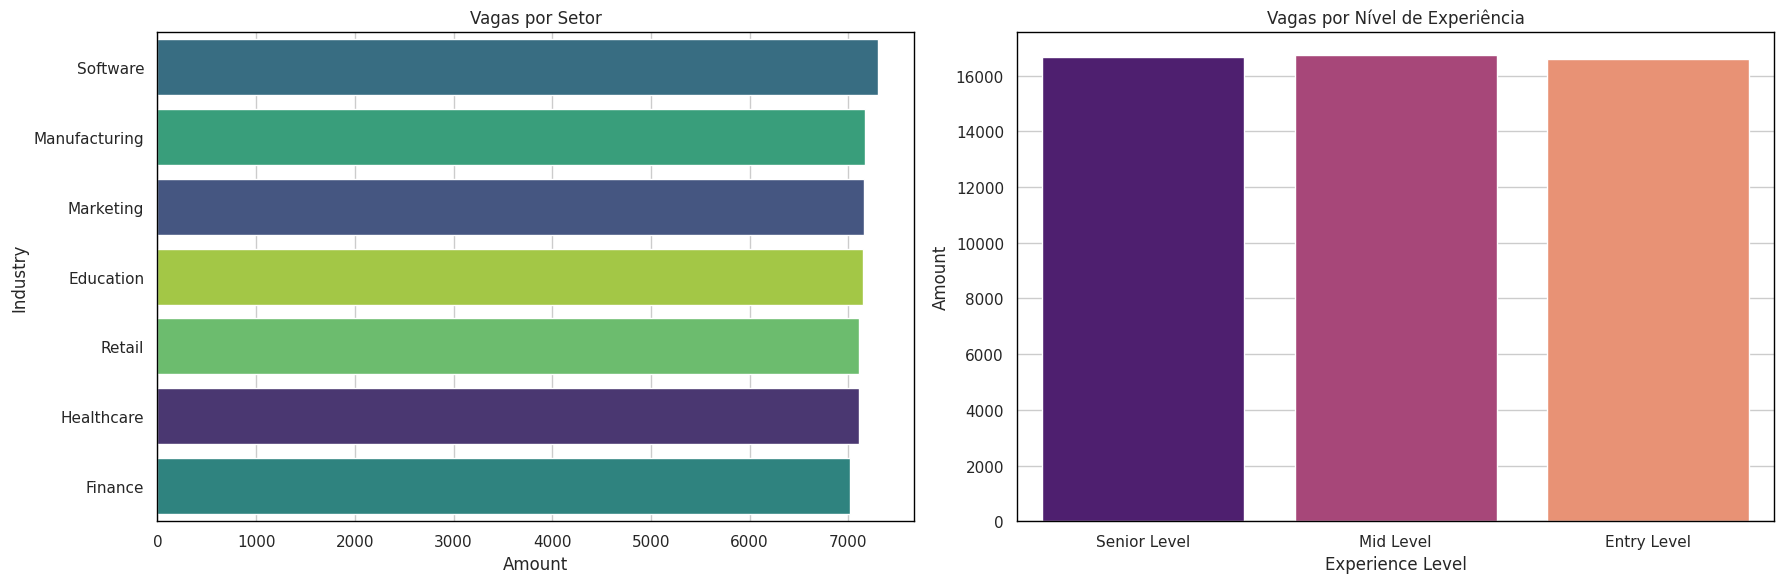

In [ ]:
print("Informações do Dataset:")
df.info()

print("\nValores Nulos:")
print(df.isnull().sum())

print("\nEstatísticas Descritivas:")
print(df.describe().iloc[:, :2])
print("\n")


'''
# Visualização: Vagas por Setor
plt.figure(figsize=(10, 5))
sns.countplot(y='Industry', data=df, order=df['Industry'].value_counts().index, palette='viridis', hue='Industry', legend=False)
plt.title('Vagas por Setor')
plt.xlabel('Amount')
plt.show()

# Visualização: Vagas por Nível de Experiência
plt.figure(figsize=(10, 5))
sns.countplot(x='Experience Level', data=df, palette='magma', hue='Experience Level', legend=False)
plt.title('Vagas por Nível de Experiência')
plt.ylabel('Amount')
plt.show()'''

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for spine in axes[0].spines.values():
    spine.set_linewidth(1)
    spine.set_color('black')

sns.countplot(ax=axes[0], y='Industry', data=df,
              order=df['Industry'].value_counts().index,
              palette='viridis', hue='Industry', legend=False)
axes[0].set_title('Vagas por Setor')
axes[0].set_xlabel('Amount')

sns.countplot(ax=axes[1], x='Experience Level', data=df,
              palette='magma', hue='Experience Level', legend=False)
axes[1].set_title('Vagas por Nível de Experiência')
axes[1].set_ylabel('Amount')

for spine in axes[1].spines.values():
    spine.set_linewidth(1)
    spine.set_color('black')

plt.tight_layout()
plt.show()

### 3. Limpeza e Preparação dos Dados
Remoção de registros inválidos e padronização dos textos (conversão para minúsculas e remoção de pontuação) para facilitar a modelagem.


In [ ]:
# Remoção de nulos e duplicados
df = df.dropna(subset=['Required Skills', 'Job Title'])
df = df.drop_duplicates()

# Função de padronização textual
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# Aplicação da limpeza na coluna de habilidades
df['Clean_Skills'] = df['Required Skills'].apply(clean_text)
display(df[['Required Skills', 'Clean_Skills']].head())

,Required Skills,Clean_Skills
0,Pharmaceuticals,pharmaceuticals
1,"Google Ads, SEO, Content Writing",google ads seo content writing
2,"Patient Care, Nursing, Medical Research, Pharm...",patient care nursing medical research pharmace...
3,Machine Learning,machine learning
4,"Nursing, Medical Research, Pharmaceuticals",nursing medical research pharmaceuticals


### 4. Filtragem dos Dados
Remove vagas inconsistentes e não relacionadas à tecnologia antes da vetorização.


In [ ]:
print("Recarregando dataset original")
df = pd.read_csv('job_recommendation_dataset.csv')

# Limpar e padronizar textos
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['Clean_Skills'] = df['Required Skills'].apply(clean_text)

print(f"Dataset recarregado com {len(df)} vagas")

original_count = len(df)
print(f"Vagas antes da filtragem: {original_count}")

# Palavras-chave de títulos não relacionados à tecnologia
non_tech_titles = ['arboriculturist', 'ambulance', 'lobbyist', 'bookseller', 'osteopath',
                   'teacher', 'psychologist', 'assistant', 'designer', 'psychotherapist',
                   'nurse', 'doctor', 'pharmacist', 'veterinarian', 'dentist', 'lawyer',
                   'accountant', 'chef', 'driver', 'cleaner', 'security', 'cashier',
                   'bartender', 'waiter', 'receptionist', 'housekeeper', 'painter',
                   'plumber', 'electrician', 'carpenter', 'mechanic', 'farmer']

# Palavras-chave de títulos relacionados à tecnologia
tech_titles = ['software', 'engineer', 'developer', 'data', 'analyst', 'scientist',
               'architect', 'devops', 'sysadmin', 'network', 'security', 'cloud',
               'frontend', 'backend', 'fullstack', 'ios', 'android', 'java', 'python',
               'machine learning', 'ai', 'artificial intelligence', 'database',
               'business intelligence', 'bi', 'etl', 'data warehouse', 'big data']

# Habilidades comuns na área de tecnologia
tech_skills = ['python', 'java', 'sql', 'machine learning', 'deep learning',
               'aws', 'azure', 'cloud', 'docker', 'kubernetes', 'react',
               'angular', 'node', 'javascript', 'typescript', 'c++', 'c#',
               'data science', 'analytics', 'tableau', 'power bi', 'nosql',
               'tensorflow', 'pytorch', 'keras', 'pandas', 'numpy', 'scikit',
               'linux', 'git', 'devops', 'agile', 'scrum', 'api', 'rest']

# Verifica título da vaga
def is_tech_title(job_title):
    title_lower = str(job_title).lower()
    for word in non_tech_titles:
        if word in title_lower:
            return False
    for word in tech_titles:
        if word in title_lower:
            return True
    return False

# Verifica habilidades da vaga
def has_tech_skills(skills_text):
    skill_count = 0
    for skill in tech_skills:
        if skill in skills_text.lower():
            skill_count += 1
    return skill_count >= 2

print("Filtro 1 - Removendo vagas fora da indústria de tecnologia")
tech_industries = ['Software', 'IT']
df = df[df['Industry'].isin(tech_industries)]
print(f"Vagas após filtro por indústria: {len(df)}")

print("Filtro 2 - Removendo vagas com títulos não relacionados a tecnologia")
title_filter = df['Job Title'].apply(is_tech_title)
df = df[title_filter]
print(f"Vagas após filtro por título: {len(df)}")

print("Filtro 3 - Removendo vagas com poucas habilidades de tecnologia")
skills_filter = df['Clean_Skills'].apply(has_tech_skills)
df = df[skills_filter]
print(f"Vagas após filtro por habilidades: {len(df)}")

# Reseta os índices do DataFrame após a filtragem
df = df.reset_index(drop=True)

reduction_percent = ((original_count - len(df)) / original_count) * 100
print(f"Resumo da filtragem")
print(f"Vagas originais: {original_count}")
print(f"Vagas restantes: {len(df)}")
print(f"Vagas removidas: {original_count - len(df)}")
print(f"Redução de {reduction_percent:.1f}% do dataset")

Recarregando dataset original
Dataset recarregado com 50000 vagas
Vagas antes da filtragem: 50000
Filtro 1 - Removendo vagas fora da indústria de tecnologia
Vagas após filtro por indústria: 7302
Filtro 2 - Removendo vagas com títulos não relacionados a tecnologia
Vagas após filtro por título: 1518
Filtro 3 - Removendo vagas com poucas habilidades de tecnologia
Vagas após filtro por habilidades: 1021
Resumo da filtragem
Vagas originais: 50000
Vagas restantes: 1021
Vagas removidas: 48979
Redução de 98.0% do dataset


### 5. Vetorização Textual (TF-IDF)
Transformação das habilidades em texto para uma matriz matemática multidimensional. Esta é a preparação final para aplicarmos a Similaridade de Cosseno na N2.


In [ ]:
print("Vetorização TF-IDF")
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Clean_Skills'])
print(f"Matriz tf-idf gerada com formato: {tfidf_matrix.shape}")

Vetorização TF-IDF
Matriz tf-idf gerada com formato: (1021, 7)


### 6. Sistema de Recomendação baseado em conteúdo
Criação de um perfil textual combinando título da vaga e habilidades, vetorização aprimorada com bigramas e implementação da função de recomendação por similaridade de cosseno

In [ ]:
print("Sistema de recomendação aprimorado")

# Cria um perfil textual combinando título da vaga e habilidades
df['Text_Profile'] = df['Job Title'].apply(clean_text) + ' ' + df['Clean_Skills']

# Vetorização aprimorada com bigramas e limite de características
tfidf_enhanced = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=500)
tfidf_matrix_enhanced = tfidf_enhanced.fit_transform(df['Text_Profile'])

print(f"Matriz tf-idf aprimorada gerada com formato: {tfidf_matrix_enhanced.shape}")

# Recomenda vagas com base nas habilidades e nível de experiência do usuário
def recommend_jobs(user_skills, user_experience, top_n=5):
    user_text = clean_text(user_skills)
    user_vector = tfidf_enhanced.transform([user_text])
    similarities = cosine_similarity(user_vector, tfidf_matrix_enhanced).flatten()
    exp_filter = df['Experience Level'] == user_experience
    similarities = similarities * exp_filter
    top_indices = similarities.argsort()[-top_n:][::-1]
    recommendations = df.iloc[top_indices][['Job Title', 'Company', 'Experience Level', 'Required Skills']].copy()
    recommendations['Similarity'] = similarities[top_indices]
    return recommendations

print("Sistema de recomendação inicializado")

Sistema de recomendação aprimorado
Matriz tf-idf aprimorada gerada com formato: (1021, 500)
Sistema de recomendação inicializado


### 7. Teste do Sistema de Recomendação
Demonstração prática do funcionamento do recomendador com um perfil de usuário simulado

In [ ]:
print("Teste de recomendação")
print("Perfil: python, machine learning, sql")
print("Nível: Entry Level")

user_profile = "python machine learning sql"
user_exp = "Entry Level"

recomendacoes = recommend_jobs(user_profile, user_exp, top_n=5)
print(recomendacoes.to_string())

Teste de recomendação
Perfil: python, machine learning, sql
Nível: Entry Level
                   Job Title                         Company Experience Level                       Required Skills  Similarity
963            Airline pilot                  Peterson-Clark      Entry Level  React, Python, Machine Learning, SQL    0.476939
960      Engineer, petroleum                         Lee Inc      Entry Level            Machine Learning, SQL, C++    0.423894
250  Scientist, audiological  White, Stephenson and Sandoval      Entry Level            C++, Machine Learning, SQL    0.419918
50       Biomedical engineer                  Garcia-Bennett      Entry Level         Machine Learning, SQL, Python    0.405637
818          Mining engineer   Jacobs, Fitzgerald and Abbott      Entry Level              Python, Machine Learning    0.405208


### 8. Avaliação do Modelo com Precisão@k
Implementação da métrica de avaliação Precisão@5, que verifica se a vaga original está entre as 5 primeiras recomendações quando o perfil do usuário é parcialmente ocultado.

In [ ]:
# Avalia o modelo verificando se a vaga original está entre as top 5 recomendações
def evaluate_model(sample_size=100):
    hits = 0
    n_samples = min(sample_size, len(df))

    for idx in range(n_samples):
        original_skills = df.iloc[idx]['Clean_Skills']
        skills_list = original_skills.split()

        if len(skills_list) > 2:
            partial_skills = ' '.join(skills_list[:-2])
        else:
            partial_skills = original_skills

        user_vector = tfidf_enhanced.transform([partial_skills])
        similarities = cosine_similarity(user_vector, tfidf_matrix_enhanced).flatten()
        top5_indices = similarities.argsort()[-5:][::-1]

        if idx in top5_indices:
            hits += 1

    precision_at_5 = hits / n_samples
    return precision_at_5

print("Avaliação do Modelo")
precision = evaluate_model(100)
print(f"Precisão@5: {precision:.2f}")

Avaliação do Modelo
Precisão@5: 0.05


### 9. Ajuste 1 - Remoção de Stopwords Personalizadas

Remoção de termos irrelevantes como "job", "position", "required" e "experience" que não agregam valor semântico à representação vetorial, reduzindo ruído e melhorando a qualidade da similaridade entre perfis.

In [ ]:
print("Ajuste 1 - Remoção de stopwords personalizadas")

# Lista de stopwords adicionais específicas do domínio de vagas
custom_stopwords = ['english', 'job', 'position', 'role', 'required', 'experience',
                    'strong', 'knowledge', 'ability', 'skill', 'proficient', 'familiar']

# Cria novo vetorizador com stopwords personalizadas
tfidf_v2 = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=500)
tfidf_v2.set_params(stop_words=list(tfidf_v2.get_stop_words()) + custom_stopwords)
tfidf_matrix_v2 = tfidf_v2.fit_transform(df['Text_Profile'])

print(f"Matriz tf-idf com stopwords personalizadas: {tfidf_matrix_v2.shape}")

# Função que recomenda vagas usando stopwords personalizadas
def recommend_jobs_v2(user_skills, user_experience, top_n=5):
    user_text = clean_text(user_skills)
    user_vector = tfidf_v2.transform([user_text])
    similarities = cosine_similarity(user_vector, tfidf_matrix_v2).flatten()
    exp_filter = df['Experience Level'] == user_experience
    similarities = similarities * exp_filter
    top_indices = similarities.argsort()[-top_n:][::-1]
    recommendations = df.iloc[top_indices][['Job Title', 'Company', 'Experience Level', 'Required Skills']].copy()
    recommendations['Similarity'] = similarities[top_indices]
    return recommendations

# Função que avalia o modelo com stopwords personalizadas
def evaluate_model_v2(sample_size=100):
    hits = 0
    n_samples = min(sample_size, len(df))

    for idx in range(n_samples):
        original_skills = df.iloc[idx]['Clean_Skills']
        skills_list = original_skills.split()

        if len(skills_list) > 2:
            partial_skills = ' '.join(skills_list[:-2])
        else:
            partial_skills = original_skills

        user_vector = tfidf_v2.transform([partial_skills])
        similarities = cosine_similarity(user_vector, tfidf_matrix_v2).flatten()
        top5_indices = similarities.argsort()[-5:][::-1]

        if idx in top5_indices:
            hits += 1

    return hits / n_samples

precision_v2 = evaluate_model_v2(100)
print(f"Precisão@5 com stopwords personalizadas: {precision_v2:.2f}")

Ajuste 1 - Remoção de stopwords personalizadas
Matriz tf-idf com stopwords personalizadas: (1021, 500)
Precisão@5 com stopwords personalizadas: 0.05


### 10. Ajuste 2 - Ponderação por Nível de Experiência

Atribuição de pesos diferenciados aos níveis de experiência (Entry=1.0, Mid=0.8, Senior=0.5) para priorizar recomendações mais alinhadas ao perfil do candidato, evitando sugestões de vagas sênior para profissionais iniciantes.

In [ ]:
print("Ajuste 2 - Ponderação por nível de experiência")

# Função que recomenda vagas com pesos diferentes para cada nível de experiência
def recommend_jobs_weighted(user_skills, user_experience, top_n=5):
    user_text = clean_text(user_skills)
    user_vector = tfidf_enhanced.transform([user_text])
    similarities = cosine_similarity(user_vector, tfidf_matrix_enhanced).flatten()

    # Pesos maiores para níveis mais compatíveis com o perfil do usuário
    exp_weights = {
        'Entry Level': 1.0,
        'Mid Level': 0.8,
        'Senior Level': 0.5
    }

    weight = exp_weights.get(user_experience, 0.5)
    exp_boost = (df['Experience Level'] == user_experience).astype(float) * weight
    similarities = similarities + exp_boost

    top_indices = similarities.argsort()[-top_n:][::-1]
    recommendations = df.iloc[top_indices][['Job Title', 'Company', 'Experience Level', 'Required Skills']].copy()
    recommendations['Similarity'] = similarities[top_indices]

    return recommendations

# Função que avalia o modelo com ponderação por experiência
def evaluate_model_weighted(sample_size=100):
    hits = 0
    n_samples = min(sample_size, len(df))

    for idx in range(n_samples):
        original_skills = df.iloc[idx]['Clean_Skills']
        original_exp = df.iloc[idx]['Experience Level']
        skills_list = original_skills.split()

        if len(skills_list) > 2:
            partial_skills = ' '.join(skills_list[:-2])
        else:
            partial_skills = original_skills

        user_vector = tfidf_enhanced.transform([partial_skills])
        similarities = cosine_similarity(user_vector, tfidf_matrix_enhanced).flatten()

        exp_weights = {'Entry Level': 1.0, 'Mid Level': 0.8, 'Senior Level': 0.5}
        weight = exp_weights.get(original_exp, 0.5)
        exp_boost = (df['Experience Level'] == original_exp).astype(float) * weight
        similarities = similarities + exp_boost

        top5_indices = similarities.argsort()[-5:][::-1]

        if idx in top5_indices:
            hits += 1

    return hits / n_samples

precision_weighted = evaluate_model_weighted(100)
print(f"Precisão@5 com ponderação: {precision_weighted:.2f}")

print("Teste da recomendação ponderada")
print("Perfil: python, machine learning, sql")
print("Nível: Entry Level")

recomendacoes_weighted = recommend_jobs_weighted("python machine learning sql", "Entry Level", top_n=5)
print(recomendacoes_weighted.to_string())

Ajuste 2 - Ponderação por nível de experiência
Precisão@5 com ponderação: 0.00
Teste da recomendação ponderada
Perfil: python, machine learning, sql
Nível: Entry Level
                   Job Title                         Company Experience Level                       Required Skills  Similarity
963            Airline pilot                  Peterson-Clark      Entry Level  React, Python, Machine Learning, SQL    1.476939
960      Engineer, petroleum                         Lee Inc      Entry Level            Machine Learning, SQL, C++    1.423894
250  Scientist, audiological  White, Stephenson and Sandoval      Entry Level            C++, Machine Learning, SQL    1.419918
50       Biomedical engineer                  Garcia-Bennett      Entry Level         Machine Learning, SQL, Python    1.405637
818          Mining engineer   Jacobs, Fitzgerald and Abbott      Entry Level              Python, Machine Learning    1.405208


### 11. Comparação de Desempenho entre Versões

Consolidação dos resultados obtidos nas diferentes configurações do modelo para identificar qual ajuste proporcionou a maior melhoria na precisão das recomendações.

In [ ]:
print("Comparação de desempenho das versões")
print("-" * 50)
print(f"Versão baseline (apenas habilidades, unigramas): Precisão@5 = 0.00")
print(f"Versão aprimorada (título + bigramas): Precisão@5 = {precision:.2f}")
print(f"Versão com stopwords personalizadas: Precisão@5 = {precision_v2:.2f}")
print(f"Versão com ponderação por experiência: Precisão@5 = {precision_weighted:.2f}")
print("-" * 50)

# Dicionário com as precisões de cada versão
precisoes = {
    'Aprimorada (título + bigramas)': precision,
    'Stopwords personalizadas': precision_v2,
    'Ponderação por experiência': precision_weighted
}

# Identifica a melhor versão com base na maior precisão
melhor_versao = max(precisoes, key=precisoes.get)
melhor_precisao = precisoes[melhor_versao]

print(f"Melhor versão: {melhor_versao}")
print(f"Melhor precisão@5: {melhor_precisao:.2f}")

if melhor_precisao > precision:
    print(f"Melhoria de {(melhor_precisao - precision) * 100:.1f}% em relação à versão inicial")
else:
    print("Versão inicial já apresenta o melhor desempenho")

Comparação de desempenho das versões
--------------------------------------------------
Versão baseline (apenas habilidades, unigramas): Precisão@5 = 0.00
Versão aprimorada (título + bigramas): Precisão@5 = 0.05
Versão com stopwords personalizadas: Precisão@5 = 0.05
Versão com ponderação por experiência: Precisão@5 = 0.00
--------------------------------------------------
Melhor versão: Aprimorada (título + bigramas)
Melhor precisão@5: 0.05
Versão inicial já apresenta o melhor desempenho


### 12. Conclusão do Pipeline de Recomendação

Demonstração prática do sistema utilizando a configuração que obteve o melhor desempenho na avaliação, apresentando as vagas recomendadas para um perfil específico de usuário.

In [ ]:
print("Conclusão do pipeline de recomendação")
print(f"Dataset final: {len(df)} vagas de tecnologia")
print(f"Vetorização: TF-IDF com n-gramas (1,2) e {tfidf_matrix_enhanced.shape[1]} características")
print(f"Melhor precisão@5 alcançada: {melhor_precisao:.2f} ({melhor_precisao*100:.0f}%)")
print(f"Número de recomendações possíveis por perfil: Top-5")

Conclusão do pipeline de recomendação
Dataset final: 1021 vagas de tecnologia
Vetorização: TF-IDF com n-gramas (1,2) e 500 características
Melhor precisão@5 alcançada: 0.05 (5%)
Número de recomendações possíveis por perfil: Top-5
